In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
from model import build_lstm_model
from preprocessing import parse_start_time, convert_to_datetime, create_sequence, extract_features_from_cycles
import tensorflow as tf
import random

# RUL Prediction
- Data: Discharge cycle of a battery (B0005)
- Description: Use the first 50 cycles of discharge data to predict the next cycles
- Model: LSTM & GRU


In [17]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [18]:
discharge_dataset = pd.read_csv("../../dataset/processed/discharge_data.csv")

discharge_data = discharge_dataset[discharge_dataset["battery_id"] == "B0005"].copy()

### Discharge capacity fade over cycles

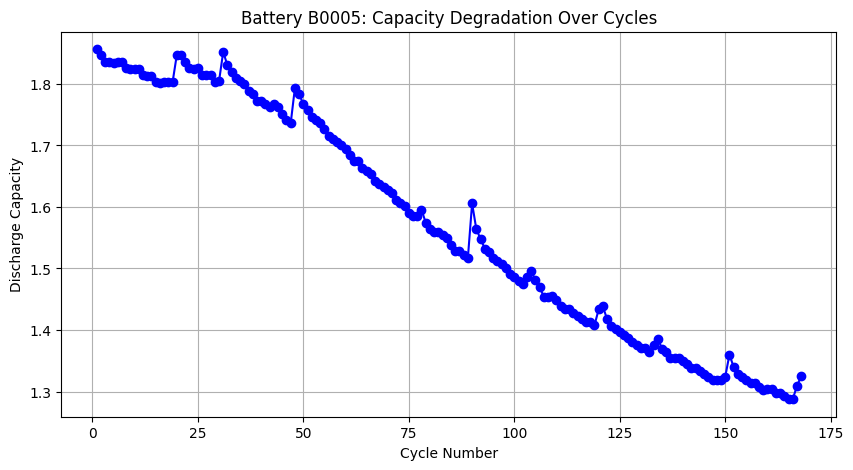

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(discharge_data["cycle_number"], discharge_data["Capacity"], marker="o", linestyle="-", color="b")

plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity")
plt.title("Battery B0005: Capacity Degradation Over Cycles")
plt.grid(True)

plt.show()

## Feature Engineering

In [20]:
data_path="../../dataset/processed/data"

extracted_features = extract_features_from_cycles(discharge_data, data_path)

discharge_data = discharge_data.merge(extracted_features, on=["cycle_number"], how="left")

100%|██████████| 168/168 [00:00<00:00, 549.63it/s]


### Convert datetime to delta_t between cycles

In [21]:
discharge_data["start_time"] = discharge_data["start_time"].apply(parse_start_time)

discharge_data["datetime"] = discharge_data["start_time"].apply(convert_to_datetime)

discharge_data["delta_time"] = (discharge_data["datetime"] - discharge_data["datetime"].iloc[0]).dt.total_seconds()

In [22]:
discharge_data.head()

,Unnamed: 0,start_time,ambient_temperature,battery_id,test_id,uid,filename_x,Capacity,cycle_number,Voltage_mean,Voltage_max,Voltage_min,Current_mean,Current_max,Temperature_mean,Temperature_max,Total_discharge_time,filename_y,datetime,delta_time
0,1,"[2008.0, 4.0, 2.0, 15.0, 25.0, 41.593]",24,B0005,1,2,00002.csv,1.856487,1,3.529829,4.191492,2.612467,-1.818702,0.000729,32.572328,38.982181,3690.234,00002.csv,2008-04-02 15:25:41.593,0.000
1,3,"[2008.0, 4.0, 2.0, 19.0, 43.0, 48.406]",24,B0005,3,4,00004.csv,1.846327,2,3.537320,4.189773,2.587209,-1.817560,0.002927,32.725235,39.033398,3672.344,00004.csv,2008-04-02 19:43:48.406,15486.813
2,5,"[2008.0, 4.0, 3.0, 0.0, 1.0, 6.687]",24,B0005,5,6,00006.csv,1.835349,3,3.543737,4.188187,2.651917,-1.816487,0.001484,32.642862,38.818797,3651.641,00006.csv,2008-04-03 00:01:06.687,30925.094
3,7,"[2008.0, 4.0, 3.0, 4.0, 16.0, 37.375]",24,B0005,7,8,00008.csv,1.835263,4,3.543666,4.188461,2.592948,-1.825589,0.001547,32.514876,38.762305,3631.563,00008.csv,2008-04-03 04:16:37.375,46255.782
4,9,"[2008.0, 4.0, 3.0, 8.0, 33.0, 25.703]",24,B0005,9,10,00010.csv,1.834646,5,3.542343,4.188299,2.547420,-1.826114,0.001701,32.382349,38.665393,3629.172,00010.csv,2008-04-03 08:33:25.703,61664.110


In [23]:
# Data used for modelling
discharge_data = discharge_data[["cycle_number", "Capacity", "delta_time",
                                 "Voltage_mean", "Voltage_max", "Voltage_min",
                                 "Current_mean", "Current_max",
                                 "Temperature_mean", "Temperature_max", "Total_discharge_time",
                                 ]].copy()

In [24]:
discharge_data.head()

,cycle_number,Capacity,delta_time,Voltage_mean,Voltage_max,Voltage_min,Current_mean,Current_max,Temperature_mean,Temperature_max,Total_discharge_time
0,1,1.856487,0.000,3.529829,4.191492,2.612467,-1.818702,0.000729,32.572328,38.982181,3690.234
1,2,1.846327,15486.813,3.537320,4.189773,2.587209,-1.817560,0.002927,32.725235,39.033398,3672.344
2,3,1.835349,30925.094,3.543737,4.188187,2.651917,-1.816487,0.001484,32.642862,38.818797,3651.641
3,4,1.835263,46255.782,3.543666,4.188461,2.592948,-1.825589,0.001547,32.514876,38.762305,3631.563
4,5,1.834646,61664.110,3.542343,4.188299,2.547420,-1.826114,0.001701,32.382349,38.665393,3629.172


In [25]:
features = ["Capacity", "delta_time", "Voltage_mean", "Voltage_max", "Voltage_min","Current_mean", "Current_max",
            "Temperature_mean", "Temperature_max", "Total_discharge_time"]
target = "Capacity"

len(features)

10

# Build model

## Data preprocessing

In [26]:
sequence_length = 15

X, y = create_sequence(discharge_data[features], sequence_length, target)

# (samples, timesteps, features)
X.shape, y.shape

((153, 15, 10), (153,))

In [27]:
X_train, y_train = X[:120], y[:120]
X_val, y_val = X[120:140], y[120:140]
X_test, y_test = X[140:], y[140:]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((120, 15, 10), (120,), (20, 15, 10), (20,), (13, 15, 10), (13,))

In [28]:
from sklearn.preprocessing import MinMaxScaler
from preprocessing import data_scaling

X_train, scaler = data_scaling(X_train)
X_val, _ = data_scaling(X_val, scaler)
X_test, _ = data_scaling(X_test, scaler)

### LSTM

In [29]:
from keras.api.models import Sequential
from keras.api.layers import *
from keras.api.metrics import RootMeanSquaredError
from keras.api.regularizers import L2

In [30]:
model = Sequential()

model.add(InputLayer((sequence_length, len(features))))

model.add(LSTM(64, return_sequences=True, activation='tanh'))
model.add(Dropout(0.2))

model.add(LSTM(32, return_sequences=False, activation='tanh'))
model.add(Dropout(0.2))

model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 15, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,889 (124.57 KB)

 Trainable params: 31,889 (124.57 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint

# Callback to stop training when validation loss stops improving
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

cp = ModelCheckpoint('models/model.keras', save_best_only=True, monitor='val_loss')
model.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [32]:
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[es, cp], verbose=1)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - loss: 2.6105 - root_mean_squared_error: 1.6148 - val_loss: 0.7081 - val_root_mean_squared_error: 0.8415
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.5470 - root_mean_squared_error: 1.2423 - val_loss: 0.1661 - val_root_mean_squared_error: 0.4075
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.6770 - root_mean_squared_error: 0.8208 - val_loss: 0.0206 - val_root_mean_squared_error: 0.1437
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1743 - root_mean_squared_error: 0.4152 - val_loss: 0.3969 - val_root_mean_squared_error: 0.6300
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.1876 - root_mean_squared_error: 0.4320 - val_loss: 0.4304 - val_root_mean_squared_error: 0.6561
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1620 - root_mean_squared_error: 0.4017 - val_loss: 0.1944 - val_root_mean_squared_error: 0.4409
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0827 - roo

## Evaluate the result

In [33]:
from keras.api.models import load_model
model1 = load_model('models/model.keras')

In [34]:
train_loss, train_rmse = model.evaluate(X_train, y_train)
val_loss, val_rmse = model.evaluate(X_val, y_val)
test_loss, test_rmse = model.evaluate(X_test, y_test)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {val_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.5888e-04 - root_mean_squared_error: 0.0236 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.1871e-04 - root_mean_squared_error: 0.0109
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 3.9406e-04 - root_mean_squared_error: 0.0199
Train RMSE: 0.0245
Validation RMSE: 0.0109
Test RMSE: 0.0199


In [35]:
train_predictions = model.predict(X_train).flatten()
train_results = pd.DataFrame(data={'Train Predictions':train_predictions, 'Actuals': y_train})
train_results['Cycle Number'] = discharge_data.iloc[:len(train_predictions)]['cycle_number'].values[:len(train_predictions)] + 15
train_results

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


,Train Predictions,Actuals,Cycle Number
0,1.787564,1.802107,16
1,1.790725,1.802580,17
2,1.793192,1.803068,18
3,1.794666,1.802778,19
4,1.795210,1.847026,20
...,...,...,...
115,1.372360,1.370509,131
116,1.368005,1.364736,132
117,1.365650,1.375392,133
118,1.362792,1.386112,134


In [36]:
validate_predictions = model.predict(X_val).flatten()
val_results = pd.DataFrame(data={ 'Validate Predictions':validate_predictions, 'Actuals':y_val})
val_results['Cycle Number'] = discharge_data.iloc[120:140]['cycle_number'].values[:len(validate_predictions)] + sequence_length
val_results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


,Validate Predictions,Actuals,Cycle Number
0,1.355713,1.364783,136
1,1.352224,1.354322,137
2,1.350754,1.354642,138
3,1.346875,1.354704,139
4,1.343750,1.349315,140
5,1.342107,1.344189,141
6,1.340422,1.338991,142
7,1.338900,1.338915,143
8,1.337859,1.334007,144
9,1.335381,1.328644,145


In [37]:
test_predictions = model.predict(X_test).flatten()
test_results = pd.DataFrame(data={'Test Predictions':test_predictions, 'Actuals':y_test})
test_results['Cycle Number'] = discharge_data.iloc[140:]['cycle_number'].values[:len(test_predictions)] + sequence_length
test_results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


,Test Predictions,Actuals,Cycle Number
0,1.326962,1.313475,156
1,1.326699,1.313202,157
2,1.327620,1.307796,158
3,1.325686,1.303033,159
4,1.324687,1.303357,160
5,1.323181,1.303410,161
6,1.321282,1.297887,162
7,1.318977,1.298074,163
8,1.315316,1.293464,164
9,1.313281,1.288003,165


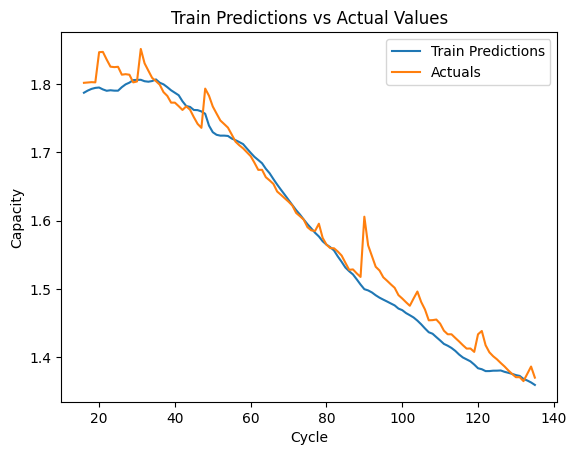

In [38]:
import matplotlib.pyplot as plt
plt.plot(train_results['Cycle Number'], train_results['Train Predictions'], label='Train Predictions')
plt.plot(train_results['Cycle Number'], train_results['Actuals'], label='Actuals')

plt.xlabel("Cycle")
plt.ylabel("Capacity")
plt.title("Train Predictions vs Actual Values")
plt.legend()
plt.show()

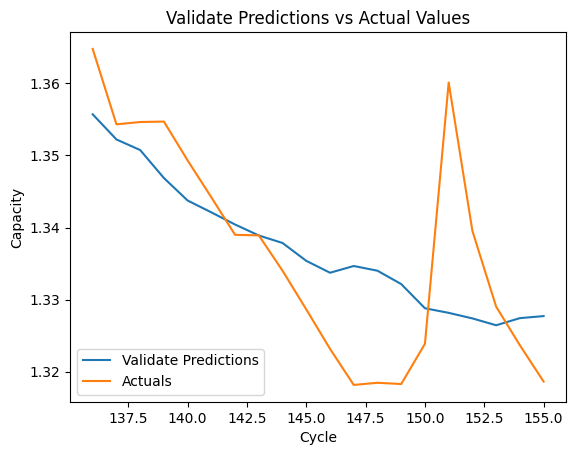

In [39]:
import matplotlib.pyplot as plt
plt.plot(val_results['Cycle Number'], val_results['Validate Predictions'], label='Validate Predictions')
plt.plot(val_results['Cycle Number'], val_results['Actuals'], label='Actuals')

plt.xlabel("Cycle")
plt.ylabel("Capacity")
plt.title("Validate Predictions vs Actual Values")
plt.legend()
plt.show()

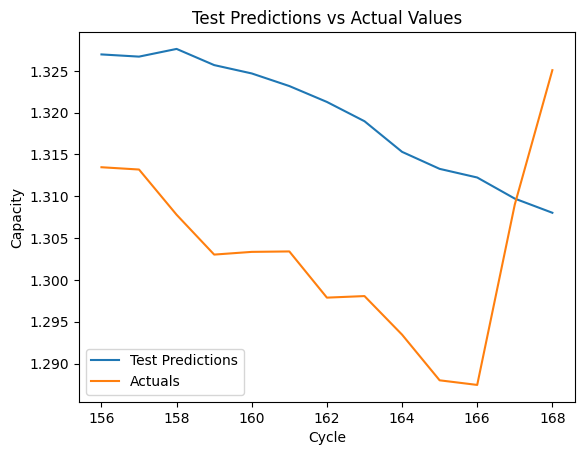

In [40]:
import matplotlib.pyplot as plt
plt.plot(test_results['Cycle Number'], test_results['Test Predictions'], label='Test Predictions')
plt.plot(test_results['Cycle Number'], test_results['Actuals'], label='Actuals')

plt.xlabel("Cycle")
plt.ylabel("Capacity")
plt.title("Test Predictions vs Actual Values")
plt.legend()
plt.show()

In [41]:
val_predictions = model.predict(X_val).flatten()
val_results = pd.DataFrame(data={'Val Predictions':val_predictions, 'Actuals':y_val})
val_results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


,Val Predictions,Actuals
0,1.355713,1.364783
1,1.352224,1.354322
2,1.350754,1.354642
3,1.346875,1.354704
4,1.343750,1.349315
5,1.342107,1.344189
6,1.340422,1.338991
7,1.338900,1.338915
8,1.337859,1.334007
9,1.335381,1.328644


In [42]:
import matplotlib.pyplot as plt
cycle_predictions = np.concatenate((train_predictions, val_predictions, test_predictions))
y_actuals = np.concatenate((y_train, y_val, y_test))
cycle_results = pd.DataFrame(data={'Cycle Predictions':cycle_predictions, 'Actuals':y_actuals})
cycle_results['Cycle Number'] = discharge_data['cycle_number'].values[:len(cycle_predictions)] + sequence_length

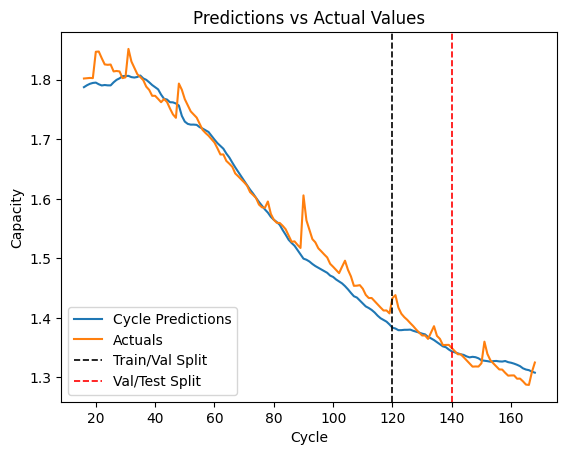

In [43]:
# Evaluate the whole cycle between actual and prediction
plt.plot(cycle_results['Cycle Number'], cycle_predictions, label='Cycle Predictions')
plt.plot(cycle_results['Cycle Number'], y_actuals, label='Actuals')

plt.axvline(x=120, color="k", linestyle="--", linewidth=1.2, label="Train/Val Split")
plt.axvline(x=140, color="r", linestyle="--", linewidth=1.2, label="Val/Test Split")

plt.xlabel("Cycle")
plt.ylabel("Capacity")
plt.title("Predictions vs Actual Values")
plt.legend()
plt.show()
